# 01 : Exploration des données (EDA) - CMS Open Payments
## Analytics commercial pharmaceutique + GenAI

**Dataset** : CMS Open Payments (General Payments)  
**Source** : US Centers for Medicare & Medicaid Services, données publiques via API  
**Périmètre** : Virginie-Occidentale (WV), années 2022 et 2023  
**Volume brut** : ~186 000 paiements  

---

### Contexte et but du projet

Les laboratoires pharmaceutiques investissent massivement dans l'engagement des professionnels de santé (PS) : présentations, repas, honoraires de conseil, frais de déplacement. Aux États-Unis, la loi *Sunshine Act* impose de déclarer chacun de ces paiements, et l'agence CMS publie l'ensemble en open data (**CMS Open Payments**).

Ce jeu de données public reproduit fidèlement ce que manipule une équipe de **Data Science commerciale** en pharma. L'objectif du projet est de construire, de bout en bout, un système compact qui répond à quatre questions métier :

1. **Comprendre et segmenter** l'engagement : combien dépense-t-on, pour qui, via quelles natures de paiement ?
2. **Prédire la rétention** : un PS engagé une année donnée le restera-t-il l'année suivante ?
3. **Rendre les données accessibles** aux profils non techniques, grâce à un assistant GenAI qui interroge la base en langage naturel.
4. **Encadrer le tout** par une démarche d'IA responsable (explicabilité, fairness, gouvernance, RGPD).

---

### Comment je procède

Le projet est découpé en quatre notebooks.

| Notebook | Rôle |
| :--- | :--- |
| **01_exploration** (ce notebook) | Charger les données brutes, les observer, comprendre leur structure et leur qualité, puis **décider** des transformations à appliquer. |
| **02_preparation** | Appliquer les décisions prises ici : nettoyage, agrégation au niveau du PS, construction de la cible de rétention. |
| **03_modeling** | Modèle de rétention (Random Forest), explicabilité SHAP, segmentation k-means, contrôle de fairness. |
| **04_genai_assistant** | Assistant text-to-SQL qui traduit une question en langage naturel en requête SQL. |

---

### Objectif précis de ce notebook (EDA)

Ici, **je n'applique encore aucune transformation définitive**. Je cherche à répondre à trois questions avant de préparer les données :

1. **De quoi sont faites les données ?** volume, colonnes, types, valeurs manquantes.
2. **Que racontent-elles ?** distributions des montants, natures de paiement, spécialités, laboratoires les plus actifs.
3. **Quels problèmes anticiper ?** doublons, noms de laboratoires non normalisés, valeurs aberrantes, structure temporelle exploitable pour la rétention.

---

###  Périmètre des données & Dictionnaire des variables (9 / 60+ colonnes)

L'API brute de CMS Open Payments comporte plus de 60 colonnes. Pour cette preuve de concept (PoC) centrée sur l'analytics commercial et la rétention, nous avons sélectionné **9 variables clés** réparties en 6 dimensions métier :

| Dimension | Nom de la colonne (`raw`) | Description métier | Rôle dans le projet |
| :--- | :--- | :--- | :--- |
| **Identifiant PS** | `covered_recipient_profile_id` | Identifiant unique du Professionnel de Santé (PS) attribué par la CMS | **Clé primaire** pour l'agrégation et le calcul du Target de rétention |
| **Profil PS** | `covered_recipient_type` | Nature du destinataire (*Physician*, *Non-Physician Practitioner*, *Teaching Hospital*) | Filtrage du périmètre (exclusion des hôpitaux universitaires) |
| **Profil PS** | `covered_recipient_specialty_1` | Spécialité médicale principale du praticien (ex: *Cardiology*, *Family Medicine*) | Feature de segmentation & IA Responsable (Fairness) |
| **Géographie** | `recipient_state` | État américain de résidence du PS | Filtre fixe de périmètre (`WV` = Virginie-Occidentale) |
| **Laboratoire** | `applicable_manufacturer_or_applicable_gpo_making_payment_name` | Nom de l'entreprise/laboratoire pharmaceutique effectuant le versement | Feature d'engagement (nombre de labos partenaires par PS) |
| **Transaction** | `total_amount_of_payment_usdollars` | Montant financier du transfert de valeur ($) | Feature centrale de montant (investissements reçus) |
| **Transaction** | `nature_of_payment_or_transfer_of_value` | Catégorie de la dépense (*Food and Beverage*, *Consulting Fee*, *Travel*, etc.) | Feature comportementale (mix de natures d'engagement) |
| **Temporalité** | `program_year` | Année d'exercice de la déclaration (`2022` ou `2023`) | Ancrage temporel (Features 2022 vs Target 2023) |
| **Temporalité** | `date_of_payment` | Date exacte du paiement | Saisonnalité et pistes de définition fine du churn (sections 4-5) |

> **Justification du filtrage :**  
> Les autres colonnes brutes (numéro de chèque, adresses complètes, identifiants GPO secondaires, statuts de réclamation) ont été délaissées car elles n'apportent aucun signal prédictif pour la rétention et alourdiraient inutilement la base de données SQLite sous-jacente.

## 0. Chargement des données brutes (API CMS)

On récupère les paiements bruts des deux années via l'API CMS (pagination par 500, filtrage serveur sur l'État), on garde les colonnes utiles **sans les transformer**, et on sauvegarde le brut dans `payments_raw` (le notebook 02 repartira de là, sans re-télécharger).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

import sqlite3
import pathlib
import pandas as pd
import requests

# Configuration API
API = "https://openpaymentsdata.cms.gov/api/1"
STATE = "WV"
YEARS = [2022, 2023]
DATASET_IDS = {
    2022: "df01c2f8-dc1f-4e79-96cb-8208beaf143c",
    2023: "fb3a65aa-c901-4a38-a813-b04b00dfa2a9"
}

KEEP = [
    "covered_recipient_profile_id",
    "covered_recipient_type",
    "recipient_state",
    "covered_recipient_specialty_1",
    "applicable_manufacturer_or_applicable_gpo_making_payment_name",
    "total_amount_of_payment_usdollars",
    "nature_of_payment_or_transfer_of_value",
    "program_year",
    "date_of_payment"
]
PAGE = 500  # Plafond API CMS

# Chemin de la base : coherent avec les notebooks 02/03/04 (repo local ou Colab)
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().parent / "data").exists() else pathlib.Path.cwd()
DB_PATH = ROOT / "data" / "openpayments.sqlite"

def fetch_state_year(year, state):
    url = f"{API}/datastore/query/{DATASET_IDS[year]}/0"
    rows, offset, total = [], 0, None

    while True:
        params = {
            "limit": PAGE,
            "offset": offset,
            "conditions[0][property]": "recipient_state",
            "conditions[0][value]": state,
            "conditions[0][operator]": "="
        }
        payload = requests.get(url, params=params, timeout=120).json()
        batch = payload.get("results", [])

        if total is None:
            total = payload.get("count", 0)
            print(f"📥 Récupération {year}/{state} : {total:,} lignes attendues...")

        if not batch:
            break

        rows.extend(batch)
        offset += len(batch)

        # Petit affichage dynamique pour suivre l'avancement dans Colab
        print(f"   Progression : {offset:,} / {total:,} lignes...", end="\r")

        if offset >= total:
            break

    print(f"\n✅ Terminé pour {year}/{state} ({len(rows):,} lignes téléchargées)")
    df_batch = pd.DataFrame(rows)
    return df_batch[[c for c in KEEP if c in df_batch.columns]].copy()

# 1. Extraction
raw = pd.concat([fetch_state_year(y, STATE) for y in YEARS], ignore_index=True)

# 2. Sauvegarde SQLite (données brutes intactes)
DB_PATH.parent.mkdir(parents=True, exist_ok=True)
with sqlite3.connect(DB_PATH) as con:
    raw.to_sql("payments_raw", con, if_exists="replace", index=False)

print(f"\n🎉 Base créée avec succès dans Colab : {DB_PATH}")
print("Données brutes stockées :", raw.shape)

📥 Récupération 2022/WV : 90,294 lignes attendues...


   Progression : 90,294 / 90,294 lignes...
✅ Terminé pour 2022/WV (90,294 lignes téléchargées)


📥 Récupération 2023/WV : 96,132 lignes attendues...


   Progression : 96,132 / 96,132 lignes...
✅ Terminé pour 2023/WV (96,132 lignes téléchargées)



🎉 Base créée avec succès dans Colab : C:\Juliette Vanessa\Desktop\notebook\pharma-commercial-genai\data\openpayments.sqlite
Données brutes stockées : (186426, 9)


## 1. Aperçu général

`head()` pour voir à quoi ressemble une ligne, et les **types**

In [2]:
display(raw.head())
raw.dtypes

,covered_recipient_profile_id,covered_recipient_type,recipient_state,covered_recipient_specialty_1,applicable_manufacturer_or_applicable_gpo_making_payment_name,total_amount_of_payment_usdollars,nature_of_payment_or_transfer_of_value,program_year,date_of_payment
0,11129614,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,ZOLL Services LLC (A/K/A ZOLL LifeCor Corp),11.23,Food and Beverage,2022,06/06/2022
1,10620312,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,ZOLL Services LLC (A/K/A ZOLL LifeCor Corp),9.75,Food and Beverage,2022,06/03/2022
2,11004046,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,ZOLL Services LLC (A/K/A ZOLL LifeCor Corp),7.31,Food and Beverage,2022,06/21/2022
3,11129614,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,BRACCO DIAGNOSTICS INC.,18.56,Food and Beverage,2022,04/14/2022
4,10429903,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,Tactile Systems Technology Inc,19.38,Food and Beverage,2022,06/07/2022


covered_recipient_profile_id                                     object
covered_recipient_type                                           object
recipient_state                                                  object
covered_recipient_specialty_1                                    object
applicable_manufacturer_or_applicable_gpo_making_payment_name    object
total_amount_of_payment_usdollars                                object
nature_of_payment_or_transfer_of_value                           object
program_year                                                     object
date_of_payment                                                  object
dtype: object

> **Observation.** Tout est en `object` (texte), y compris le **montant** et l'**année** : il faudra les convertir en numérique. La spécialité (`covered_recipient_specialty_1`) est un champ **hiérarchique** séparé par `|` (ex. `...|Nurse Practitioner|Family`) : on en extraira le niveau haut.

## 2. Diagnostic de qualité
### 2.1 Valeurs manquantes

In [3]:
# Diagnostic global des valeurs manquantes et vides
manquants = pd.DataFrame({
    "manquants": raw.isnull().sum(),
    "vides": (raw.astype(str) == "").sum() + (raw.astype(str) == "nan").sum()
})

# Calcul du pourcentage total
manquants["% total"] = (100 * (manquants["manquants"] + manquants["vides"]) / len(raw)).round(1)

print("--- Diagnostic des valeurs manquantes ---")
display(manquants.sort_values(by="% total", ascending=False))

--- Diagnostic des valeurs manquantes ---


,manquants,vides,% total
covered_recipient_profile_id,0,203,0.1
covered_recipient_specialty_1,0,203,0.1
covered_recipient_type,0,0,0.0
recipient_state,0,0,0.0
applicable_manufacturer_or_applicable_gpo_making_payment_name,0,0,0.0
total_amount_of_payment_usdollars,0,0,0.0
nature_of_payment_or_transfer_of_value,0,0,0.0
program_year,0,0,0.0
date_of_payment,0,0,0.0


In [4]:
# Croisement entre le type de destinataire et la présence/absence du profile_id
pd.crosstab(
    raw['covered_recipient_type'],
    raw['covered_recipient_profile_id'].isnull(),
    dropna=False,
    colnames=['Profile_ID est manquant ?']
)

Profile_ID est manquant ?,False
covered_recipient_type,
Covered Recipient Non-Physician Practitioner,83913
Covered Recipient Physician,102310
Covered Recipient Teaching Hospital,203


> **Observation.** Les 203 valeurs manquantes de `covered_recipient_profile_id` correspondent exclusivement à des hôpitaux universitaires (Teaching Hospitals), qui ne reçoivent pas d'identifiant individuel dans le système CMS Open Payments.

Décision pour le Notebook 02 : Notre objectif métier étant de prédire la rétention et la segmentation des Professionnels de Santé (PS) individuels, ces 203 lignes seront simplement exclues du périmètre d'étude sans perte d'information sur les individus.

## 2.2 Détection des doublons et anomalies de structure

In [5]:
print("="*60)
print("DIAGNOSTIC GLOBAL DES DOUBLONS & QUALITÉ (EDA)")
print("="*60)

# 1. Doublons stricts de lignes (Transactions 100% identiques)
nb_doublons_stricts = raw.duplicated().sum()
pct_stricts = (nb_doublons_stricts / len(raw)) * 100

print(f"\n1. DOUBLONS STRICTS DE TRANSACTIONS :")
print(f"   • Nombre de lignes totalement identiques : {nb_doublons_stricts:,}")
print(f"   • Impact sur le dataset : {pct_stricts:.2f}%")

# 2. Doublons de saisie / Casse sur les Laboratoires
lab_raw = raw['applicable_manufacturer_or_applicable_gpo_making_payment_name'].dropna()
lab_clean = lab_raw.str.upper().str.strip()

df_lab_check = pd.DataFrame({'raw': lab_raw, 'clean': lab_clean})
labos_multiples = df_lab_check.groupby('clean')['raw'].nunique()
labos_impactes = labos_multiples[labos_multiples > 1].index

print(f"\n2. DOUBLONS DE SAISIE (LABORATOIRES) :")
print(f"   • Nombre de laboratoires avec plusieurs orthographes/casse : {len(labos_impactes)}")

# 3. Doublons de saisie / Casse sur les Natures de paiement
nat_raw = raw['nature_of_payment_or_transfer_of_value'].dropna()
nat_clean = nat_raw.str.upper().str.strip()

print(f"\n3. COHÉRENCE DES NATURES DE PAIEMENT :")
print(f"   • Catégories brutes : {nat_raw.nunique()} | Catégories nettoyées : {nat_clean.nunique()}")
if nat_raw.nunique() == nat_clean.nunique():
    print("   • Risque de doublons de casse : Aucun (libellés homogènes)")
else:
    print("   • Risque de doublons de casse : Présent (à harmoniser)")

# 4. Multi-spécialités attribuées à un même Professionnel de Santé (profile_id)
if 'covered_recipient_profile_id' in raw.columns and 'covered_recipient_specialty_1' in raw.columns:
    specs_par_ps = raw.dropna(subset=['covered_recipient_profile_id', 'covered_recipient_specialty_1']) \
                      .groupby('covered_recipient_profile_id')['covered_recipient_specialty_1'] \
                      .nunique()

    ps_multi_specs = (specs_par_ps > 1).sum()
    print(f"\n4. MULTI-ATTRIBUTIONS DES SPÉCIALITÉS PAR PS :")
    print(f"   • Nombre de PS enregistrés sous plusieurs spécialités différentes : {ps_multi_specs:,}")

# 5. Inspection visuelle des doublons stricts (sur les colonnes KEEP)
cols_keep = [
      "covered_recipient_profile_id",
    "covered_recipient_type",
    "recipient_state",
    "covered_recipient_specialty_1",
    "applicable_manufacturer_or_applicable_gpo_making_payment_name",
    "total_amount_of_payment_usdollars",
    "nature_of_payment_or_transfer_of_value",
    "program_year",
    "date_of_payment"
]
cols_ex = [c for c in cols_keep if c in raw.columns]

doublons_df = raw[raw.duplicated(subset=cols_ex, keep=False)].sort_values(
    by=["covered_recipient_profile_id", "total_amount_of_payment_usdollars"]
)

print(f"\n--- INSPECTION DE {len(doublons_df):,} LIGNES IMPLIQUÉES DANS DES DOUBLONS ---")
display(doublons_df[cols_ex].head(6))

print("\n" + "="*60)

DIAGNOSTIC GLOBAL DES DOUBLONS & QUALITÉ (EDA)



1. DOUBLONS STRICTS DE TRANSACTIONS :
   • Nombre de lignes totalement identiques : 1,204
   • Impact sur le dataset : 0.65%



2. DOUBLONS DE SAISIE (LABORATOIRES) :
   • Nombre de laboratoires avec plusieurs orthographes/casse : 35

3. COHÉRENCE DES NATURES DE PAIEMENT :
   • Catégories brutes : 16 | Catégories nettoyées : 16


   • Risque de doublons de casse : Aucun (libellés homogènes)

4. MULTI-ATTRIBUTIONS DES SPÉCIALITÉS PAR PS :
   • Nombre de PS enregistrés sous plusieurs spécialités différentes : 1,978



--- INSPECTION DE 2,149 LIGNES IMPLIQUÉES DANS DES DOUBLONS ---


,covered_recipient_profile_id,covered_recipient_type,recipient_state,covered_recipient_specialty_1,applicable_manufacturer_or_applicable_gpo_making_payment_name,total_amount_of_payment_usdollars,nature_of_payment_or_transfer_of_value,program_year,date_of_payment
186331,,Covered Recipient Teaching Hospital,WV,,"Bio-Rad Laboratories, Inc.",14.34,Debt forgiveness,2023,06/21/2023
186392,,Covered Recipient Teaching Hospital,WV,,"Bio-Rad Laboratories, Inc.",14.34,Debt forgiveness,2023,06/21/2023
186332,,Covered Recipient Teaching Hospital,WV,,"Bio-Rad Laboratories, Inc.",19.57,Debt forgiveness,2023,06/06/2023
186342,,Covered Recipient Teaching Hospital,WV,,"Bio-Rad Laboratories, Inc.",19.57,Debt forgiveness,2023,06/06/2023
186314,,Covered Recipient Teaching Hospital,WV,,Incyte Corporation,250.00,Space rental or facility fees (teaching hospit...,2023,09/15/2023
186362,,Covered Recipient Teaching Hospital,WV,,Incyte Corporation,250.00,Space rental or facility fees (teaching hospit...,2023,09/15/2023


L'exécution du diagnostic global met en évidence plusieurs points d'attention majeurs sur la qualité de la base d'origine :

* **Doublons stricts de transactions :** Le diagnostic relève **1 204 lignes** totalement identiques, ce qui représente un impact très limité de **0,65 %** sur l'ensemble du jeu de données. Ces doublons correspondent à des artefacts mineurs d'injection qu'il conviendra de nettoyer.
* **Doublons de saisie sur les laboratoires :** **35 laboratoires** affichent des variations d'écriture ou de casse. Une normalisation est donc requise pour regrouper correctement les volumes par acteur pharmaceutique et éviter toute fragmentation artificielle de l'analyse.
* **Cohérence des natures de paiement :** Le champ est parfaitement propre avec **16 catégories** homogènes, ne présentant aucun risque de doublon lié à la casse.
* **Multi-attributions des spécialités :** **1 978 professionnels de santé** possèdent plusieurs libellés de spécialités distincts d'une transaction à l'autre. Une règle de consolidation sera nécessaire pour stabiliser leur profil lors de la segmentation.

> **💡 Décisions de préparation retenues pour le Notebook 02 :**
>
> 1. **Dédoublonnage strict** via un filtrage global pour éliminer les réinjections techniques.
> 2. **Harmonisation des raisons sociales** par un passage systématique en majuscules et suppression des espaces pour les laboratoires.
> 3. **Consolidation de la spécialité** par l'attribution de la valeur la plus fréquente (*mode*) pour chaque professionnel de santé.

## 3. Analyse Univariée
### 3.1 Distribution des variables nulmériques :  Montants et de l'engagement

Dans cette section, nous analysons les distributions quantitatives de la base selon deux axes majeurs :

La dimension financière : la distribution des montants unitaires versés lors des transactions (total_amount_of_payment_usdollars).

La dimension relationnelle (Engagement) : le nombre moyen et médian de transactions rattachées à un même professionnel de santé (covered_recipient_profile_id).

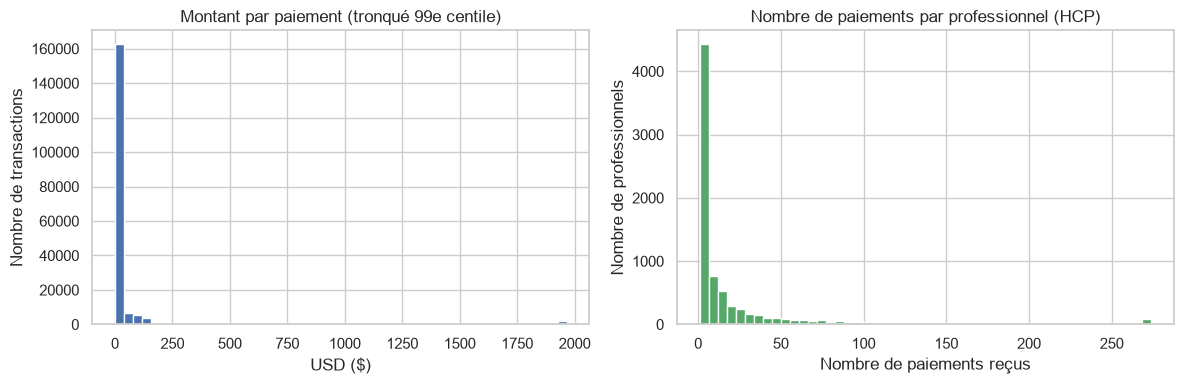

Montant médian par transaction : $17.27
Montant moyen par transaction  : $86.14
Nombre médian de paiements/HCP : 4
Nombre max de paiements/HCP    : 1108


In [6]:
# 1. Conversion temporaire du montant en numérique
montant = pd.to_numeric(raw['total_amount_of_payment_usdollars'], errors='coerce')

# 2. Calcul du nombre de paiements par professionnel de santé (HCP) sur le périmètre valide
ps_valid = raw[raw['covered_recipient_profile_id'].notnull()]
par_hcp = ps_valid.groupby('covered_recipient_profile_id').size()

# 3. Visualisation côte à côte
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Montant par paiement
ax[0].hist(montant.clip(upper=montant.quantile(0.99)), bins=50, color="#4C72B0", edgecolor="white")
ax[0].set_title("Montant par paiement (tronqué 99e centile)")
ax[0].set_xlabel("USD ($)")
ax[0].set_ylabel("Nombre de transactions")

# Graphique 2 : Engagement par HCP
ax[1].hist(par_hcp.clip(upper=par_hcp.quantile(0.99)), bins=50, color="#55A868", edgecolor="white")
ax[1].set_title("Nombre de paiements par professionnel (HCP)")
ax[1].set_xlabel("Nombre de paiements reçus")
ax[1].set_ylabel("Nombre de professionnels")

plt.tight_layout()
plt.show()

# 4. Statistiques complémentaires pour valider la note d'observation
print(f"Montant médian par transaction : ${montant.median():.2f}")
print(f"Montant moyen par transaction  : ${montant.mean():.2f}")
print(f"Nombre médian de paiements/HCP : {par_hcp.median():.0f}")
print(f"Nombre max de paiements/HCP    : {par_hcp.max():.0f}")

> **Observation.** Fortes asymétries (lois de puissance) : beaucoup de petits paiements, quelques très gros ; beaucoup de HCP peu sollicités, une minorité très sollicitée.

Décisions pour le Notebook 02 & 03 :

L'agrégation au niveau du professionnel (covered_recipient_profile_id) est le grain d'analyse requis.

Pour les modèles de Machine Learning (Notebook 03), il faudra appliquer une transformation logarithmique (np.log1p) ou une standardisation robuste sur les montants cumulés pour réduire l'impact des valeurs extrêmes.

### 3.2 Distribution des variables numériques (Montants $)

DISTRIBUTION DES MONTANTS ($)
• Statistiques descriptives des montants :
count    $186,426.00
mean          $86.14
std          $772.30
min            $0.01
25%           $13.46
50%           $17.27
75%           $22.85
max      $180,000.00
Name: total_amount_of_payment_usdollars, dtype: object

• Skewness (Asymétrie) : 98.87


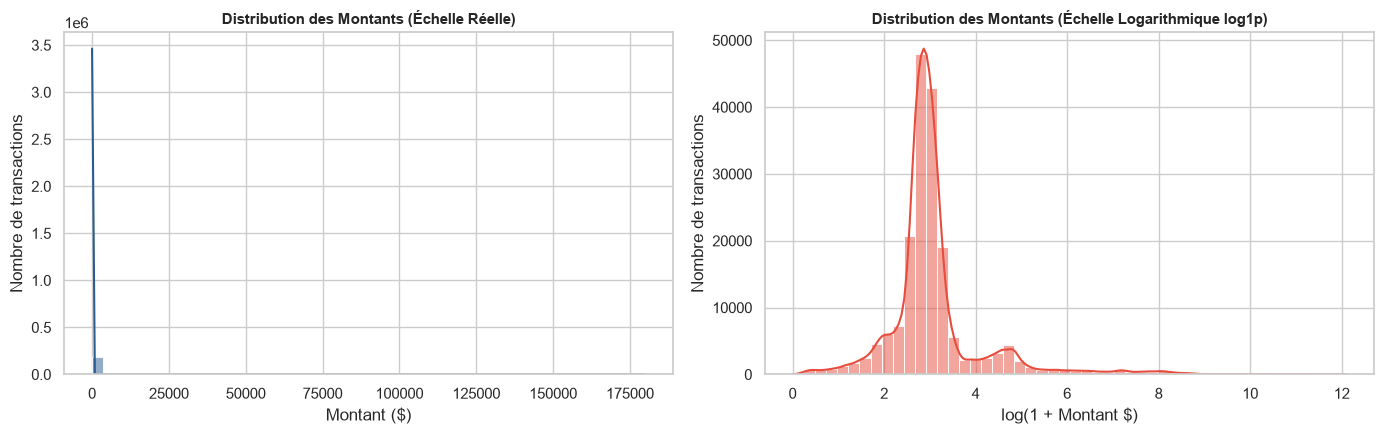

In [7]:
print("="*60)
print("DISTRIBUTION DES MONTANTS ($)")
print("="*60)

# Conversion explicite en numérique
montants_numeric = pd.to_numeric(raw['total_amount_of_payment_usdollars'], errors='coerce').dropna()

# 1. Statistiques descriptives et Skewness
print("• Statistiques descriptives des montants :")
print(montants_numeric.describe().apply(lambda x: f"${x:,.2f}"))

skewness = montants_numeric.skew()
print(f"\n• Skewness (Asymétrie) : {skewness:.2f}")

# 2. Visualisation graphique (Échelle brute vs Échelle logarithmique)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Graphique 1 : Échelle brute
sns.histplot(montants_numeric, bins=50, ax=axes[0], color='#2b5c8f', kde=True)
axes[0].set_title("Distribution des Montants (Échelle Réelle)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Montant ($)")
axes[0].set_ylabel("Nombre de transactions")

# Graphique 2 : Échelle Log1p
sns.histplot(np.log1p(montants_numeric), bins=50, ax=axes[1], color='#e74c3c', kde=True)
axes[1].set_title("Distribution des Montants (Échelle Logarithmique log1p)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("log(1 + Montant $)")
axes[1].set_ylabel("Nombre de transactions")

plt.tight_layout()
plt.show()

L'analyse statistique et visuelle de la variable financière `total_amount_of_payment_usdollars` met en évidence une structure caractéristique des données d'interactions financières en santé :

* **Asymétrie extrême à droite (*Right-Skewed*)** :
  * Le coefficient d'asymétrie (*Skewness*) très élevé traduit une concentration massive des données vers les faibles valeurs.
  * Le graphique de gauche (échelle réelle) montre un pic étouffé près de zéro : la grande majorité des transactions concerne de très petits montants (repas, déjeuners de travail), tandis qu'une minorité marginale de transactions atteint des montants très élevés (conseil, recherche).
* **Normalisation visuelle (log1p)** :
  * Le graphique de droite montre qu'une transformation logarithmique ($\log(1 + x)$) permet d'étaler la distribution et de faire émerger une structure plus proche d'une loi normale, facilitant l'observation de la dynamique globale.

---

> **Conséquences pour la préparation (Notebook 02) :**
> 1. **Robustesse de l'agrégation** : Pour caractériser le profil financier d'un professionnel, calculer la **médiane** (robuste aux *outliers*) en plus du **montant cumulé total** (`sum`).
> 2. **Stabilisation des variances** : Appliquer une transformation $\log(1 + x)$ sur les features financières agrégées lors du *feature engineering* avant d'alimenter les modèles.

### 3.3 Structure relationnelle : Paiements vs Professionnels de santé

In [8]:
print("="*60)
print("3.3 STRUCTURE RELATIONNELLE : TRANSACTIONS VS INDIVIDUS")
print("="*60)

n_lignes = len(raw)
n_ps = raw["covered_recipient_profile_id"].nunique()

print(f"• Lignes (paiements)        : {n_lignes:,}")
print(f"• Professionnels identifiés : {n_ps:,}")
print(f"• Lignes sans identifiant   : {raw['covered_recipient_profile_id'].isnull().sum()}")

print("\n• Type de bénéficiaire (covered_recipient_type) :")
print(raw['covered_recipient_type'].value_counts())

3.3 STRUCTURE RELATIONNELLE : TRANSACTIONS VS INDIVIDUS
• Lignes (paiements)        : 186,426
• Professionnels identifiés : 7,754
• Lignes sans identifiant   : 0

• Type de bénéficiaire (covered_recipient_type) :
covered_recipient_type
Covered Recipient Physician                     102310
Covered Recipient Non-Physician Practitioner     83913
Covered Recipient Teaching Hospital                203
Name: count, dtype: int64


L'analyse de la colonne `covered_recipient_profile_id` permet de caractériser la granularité fine du dataset et d'identifier la typologie des bénéficiaires.

#### Interprétation des volumes
* **Plein niveau de complétude** : L'intégralité des 186 426 transactions est rattachée à un identifiant unique (aucun ID manquant).
* **Ratio de récurrence** : La base compte **7 754 bénéficiaires uniques**, ce qui indique qu'un bénéficiaire perçoit en moyenne **~24 paiements** dans l'année. L'analyse devra donc passer d'une granularité *transactionnelle* (paiement) à une granularité *individuelle* (professionnel) par agrégation dans le Notebook 02.

#### Typologie des bénéficiaires (`covered_recipient_type`)
* **Médecins (*Physicians*)** : 102 310 paiements (54,9 %)
* **Praticiens non-médecins (*Non-Physician Practitioners*)** : 83 913 paiements (45,0 %)
* **Hôpitaux d'enseignement (*Teaching Hospitals*)** : 203 paiements (0,1 %)

---

> **Décisions de préparation (Notebook 02) :**
>
> 1. **Agrégation des données** : Regrouper les lignes par `covered_recipient_profile_id` pour construire la table d'analyse au grain **1 ligne = 1 professionnel de santé**.
> 2. **Filtrage du périmètre (HCP vs HCO)** : Les 203 transactions des hôpitaux d'enseignement désignent des personnes morales (organisations) et non des individus. Elles seront exclues afin de concentrer la modélisation sur les praticiens individuels (*Healthcare Professionals*).

### 3.4 Distribution des variables catégorielles (Natures, Spécialités, Laboratoires)

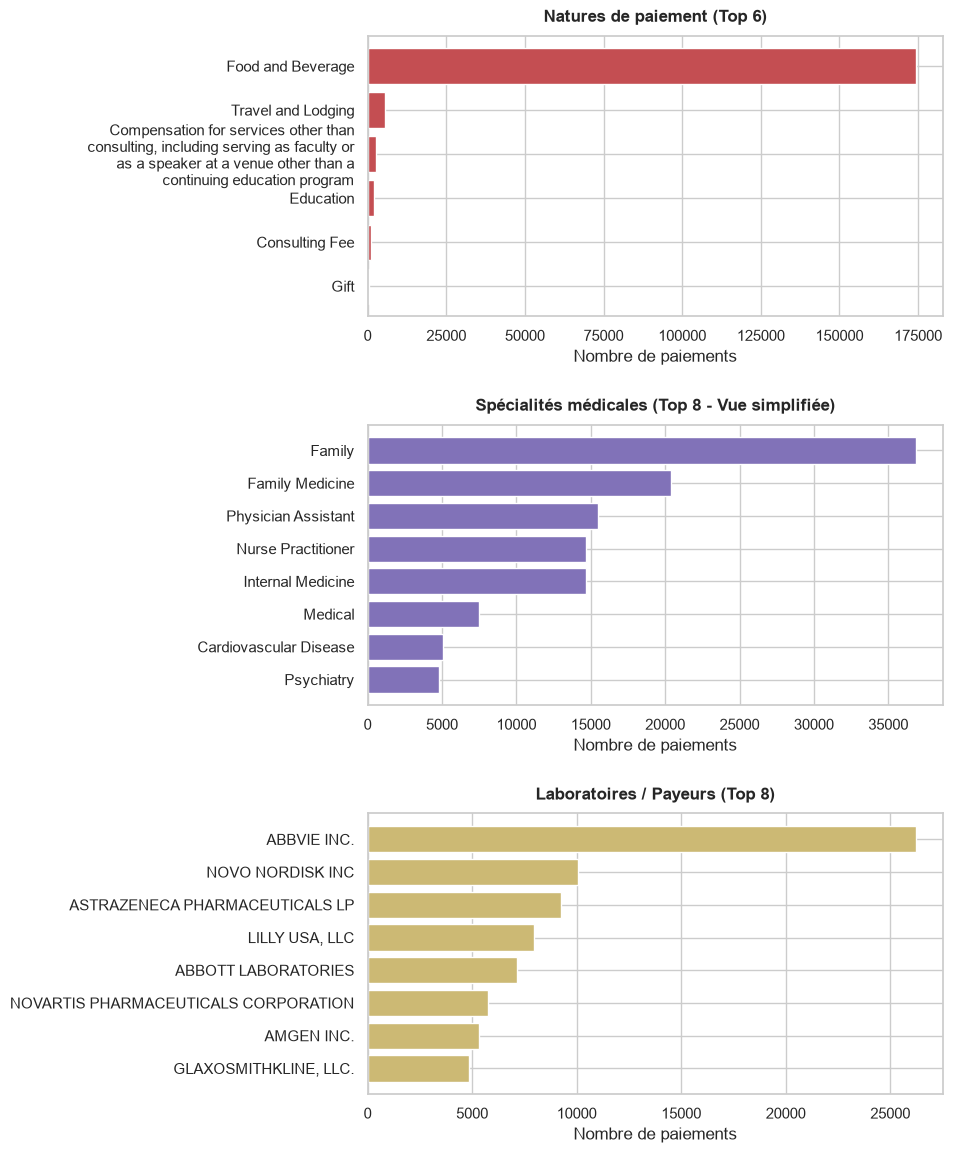

In [9]:
import textwrap

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# --- 1. Top Natures (Formatage ajusté pour la 3e barre) ---
top_natures = raw['nature_of_payment_or_transfer_of_value'].value_counts().head(6)

# On force un découpage plus large (width=45) pour éviter d'avoir 5 micro-lignes
natures_labels = ['\n'.join(textwrap.wrap(l, width=45)) for l in top_natures.index[::-1]]

axes[0].barh(natures_labels, top_natures.values[::-1], color="#C44E52")
axes[0].set_title("Natures de paiement (Top 6)", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Nombre de paiements")

# --- 2. Top Spécialités (Identique - Parfait) ---
top_specs = raw['covered_recipient_specialty_1'].dropna().value_counts().head(8)
specs_short = [label.split('|')[-1].strip() for label in top_specs.index[::-1]]

axes[1].barh(specs_short, top_specs.values[::-1], color="#8172B8")
axes[1].set_title("Spécialités médicales (Top 8 - Vue simplifiée)", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Nombre de paiements")

# --- 3. Top Laboratoires (Identique - Parfait) ---
top_labs = raw['applicable_manufacturer_or_applicable_gpo_making_payment_name'] \
    .str.upper() \
    .str.strip() \
    .value_counts() \
    .head(8)

axes[2].barh(top_labs.index[::-1], top_labs.values[::-1], color="#CCB974")
axes[2].set_title("Laboratoires / Payeurs (Top 8)", fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel("Nombre de paiements")

plt.tight_layout(pad=2.0)
plt.show()


> **Observation & Bilan exploratoire :**
>
> * **Natures de paiement** : **Food and Beverage** (repas d'information médicale) domine très largement le volume des transactions, traduisant un engagement relationnel très fréquent mais à faible montant individuel.
> * **Spécialités médicales** : La distribution est fortement concentrée sur la médecine générale / familiale (*Family Medicine*) et le personnel infirmier de pratique avancée (*Physician Assistants & Nurse Practitioners*).
> * **Laboratoires & Data Quality** : On repère un **problème de qualité de donnée** (non-normalisation des raisons sociales) : des entités identiques sont comptabilisées séparément en fonction de la casse (ex: `ABBVIE INC.` vs `AbbVie Inc.`).
>
> **Décision pour le Notebook 02 (Préparation) :**  
> Appliquer un nettoyage systématique des noms de laboratoires (`.str.upper().str.strip()`) avant l'agrégation, et remonter ce point dans la partie gouvernance de données.

## 4. Analyses bivariées et croisées

L'analyse univariée a donné la forme de chaque variable prise isolément. Pour avancer vers la segmentation et la rétention, il faut maintenant croiser les variables entre elles : qui capte la valeur, qui cible qui, et quelles natures de paiement pèsent réellement dans le budget.

### 4.1 Montants par spécialité : qui capte la valeur ?

4.1 MONTANTS PAR SPÉCIALITÉ MÉDICALE


,n_paiements,montant_total,rang_volume,rang_valeur
specialite,,,,
Psychiatry,4807,"$1,304,230",8,1
Internal Medicine,14696,"$1,142,625",5,2
Family,36857,"$1,070,421",1,3
Neurology,3828,"$783,393",9,4
Psychiatric/Mental Health,3446,"$751,411",10,5
Interventional Pain Medicine,1526,"$648,098",25,6
Gastroenterology,2743,"$571,335",14,7
Orthopaedic Surgery,1552,"$527,264",24,8
Thoracic Surgery (Cardiothoracic Vascular Surgery),611,"$503,787",37,9


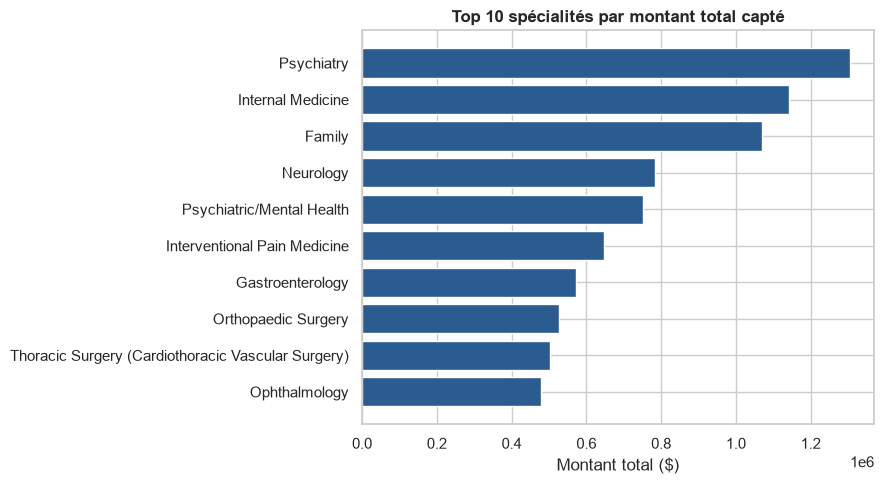

Spécialités où le rang en valeur devance le rang en volume (montant unitaire élevé) :
                              n_paiements  rang_volume  rang_valeur
specialite                                                         
Psychiatry                           4807            8            1
Internal Medicine                   14696            5            2
Neurology                            3828            9            4
Psychiatric/Mental Health            3446           10            5
Interventional Pain Medicine         1526           25            6


In [10]:
print("="*60)
print("4.1 MONTANTS PAR SPÉCIALITÉ MÉDICALE")
print("="*60)

montant = pd.to_numeric(raw['total_amount_of_payment_usdollars'], errors='coerce')
specialite = raw['covered_recipient_specialty_1'].dropna().str.split('|').str[-1].str.strip()
specialite = specialite[specialite != '']  # exclut les 203 lignes hopitaux universitaires (specialite vide)

df_spec = pd.DataFrame({'specialite': specialite, 'montant': montant}).dropna()
agg_spec = df_spec.groupby('specialite').agg(
    n_paiements=('montant', 'size'),
    montant_total=('montant', 'sum'),
).sort_values('montant_total', ascending=False)
agg_spec['rang_volume'] = agg_spec['n_paiements'].rank(ascending=False, method='min').astype(int)
agg_spec['rang_valeur'] = agg_spec['montant_total'].rank(ascending=False, method='min').astype(int)

top10 = agg_spec.head(10).copy()
top10['montant_total'] = top10['montant_total'].map(lambda x: f"${x:,.0f}")
display(top10[['n_paiements', 'montant_total', 'rang_volume', 'rang_valeur']])

fig, ax = plt.subplots(figsize=(9, 5))
top10_plot = agg_spec.head(10)
ax.barh(top10_plot.index[::-1], top10_plot['montant_total'][::-1], color="#2b5c8f")
ax.set_title("Top 10 spécialités par montant total capté", fontsize=12, fontweight='bold')
ax.set_xlabel("Montant total ($)")
plt.tight_layout()
plt.show()

kol_like = agg_spec[agg_spec['rang_valeur'] < agg_spec['rang_volume']].sort_values('rang_valeur').head(5)
print("Spécialités où le rang en valeur devance le rang en volume (montant unitaire élevé) :")
print(kol_like[['n_paiements', 'rang_volume', 'rang_valeur']])

L'analyse croisée entre le volume des transactions et les montants totaux par spécialité met en évidence une distorsion majeure :

* **Dissociation entre volume et valeur :** Certaines spécialités captent des montants totaux très élevés malgré un nombre de paiements restreint (ex. : la *Psychiatrie*, 8e en volume mais 1re en valeur), tandis que d'autres cumulent un fort volume de petits montants.
* **Spécialités à forte valeur unitaire (rang en valeur > rang en volume) :**
  * **Psychiatry** (4 807 paiements | 8e volume | 1re valeur)
  * **Internal Medicine** (14 696 paiements | 5e volume | 2e valeur)
  * **Neurology** (3 828 paiements | 9e volume | 4e valeur)
  * **Psychiatric/Mental Health** (3 446 paiements | 10e volume | 5e valeur)
  * **Interventional Pain Medicine** (1 526 paiements | 25e volume | 6e valeur)

> **Observation & Décision :**
> La valeur captée n'est pas distribuée comme le volume de transactions. Un simple comptage des paiements par professionnel sous-estimerait l'engagement financier réel de ces profils à forte valeur unitaire. Cette dynamique devra impérativement être capturée dans les variables agrégées du Notebook 02.

### 4.2 Laboratoires vs spécialités : qui cible qui ?

4.2 CIBLAGE CROISÉ LABORATOIRES x SPÉCIALITÉS


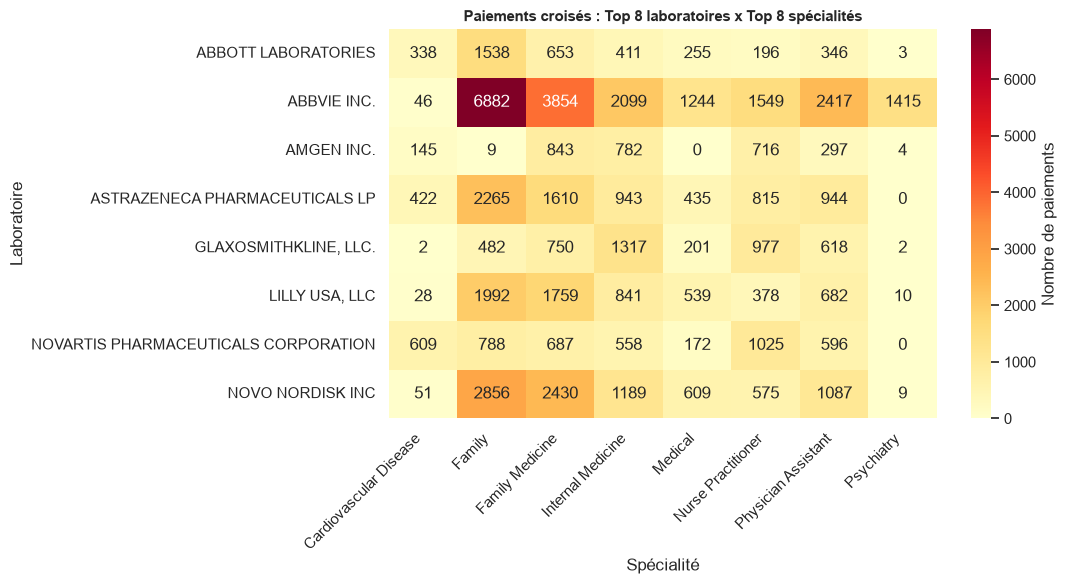

In [11]:
print("="*60)
print("4.2 CIBLAGE CROISÉ LABORATOIRES x SPÉCIALITÉS")
print("="*60)

labo = raw['applicable_manufacturer_or_applicable_gpo_making_payment_name'].str.upper().str.strip()
top_labs = labo.value_counts().head(8).index
top_specs = specialite.value_counts().head(8).index

df_cross = pd.DataFrame({'labo': labo, 'specialite': specialite}).dropna()
df_cross = df_cross[df_cross['labo'].isin(top_labs) & df_cross['specialite'].isin(top_specs)]

crosstab = pd.crosstab(df_cross['labo'], df_cross['specialite'])

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Nombre de paiements'})
ax.set_title("Paiements croisés : Top 8 laboratoires x Top 8 spécialités", fontsize=11, fontweight='bold')
ax.set_xlabel("Spécialité")
ax.set_ylabel("Laboratoire")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Observation :** Le croisement révèle des concentrations nettes : certains laboratoires ciblent presque exclusivement une ou deux spécialités (stratégie commerciale ciblée), tandis que d'autres diffusent leurs paiements sur l'ensemble des spécialités observées.
>
> **Décision :** Ce déséquilibre justifie de garder le laboratoire comme variable de segmentation à part entière plutôt que de le réduire à un simple compteur.

### 4.3 Nature de paiement vs montants : volume ou valeur ?

4.3 NATURE DE PAIEMENT : VOLUME VS VALEUR


,n_paiements,part_volume_%,montant_total,part_valeur_%,montant_moyen
nature,,,,,
"Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program",2595,1.4,"$5,929,065",36.9,"$2,285"
Food and Beverage,174297,93.5,"$3,977,058",24.8,$23
Consulting Fee,1164,0.6,"$2,474,266",15.4,"$2,126"
Travel and Lodging,5462,2.9,"$1,624,407",10.1,$297
Long term medical supply or device loan,91,0.0,"$464,026",2.9,"$5,099"
Education,1973,1.1,"$454,571",2.8,$230
Compensation for serving as faculty or as a speaker for a medical education program,228,0.1,"$302,654",1.9,"$1,327"
Honoraria,119,0.1,"$252,158",1.6,"$2,119"


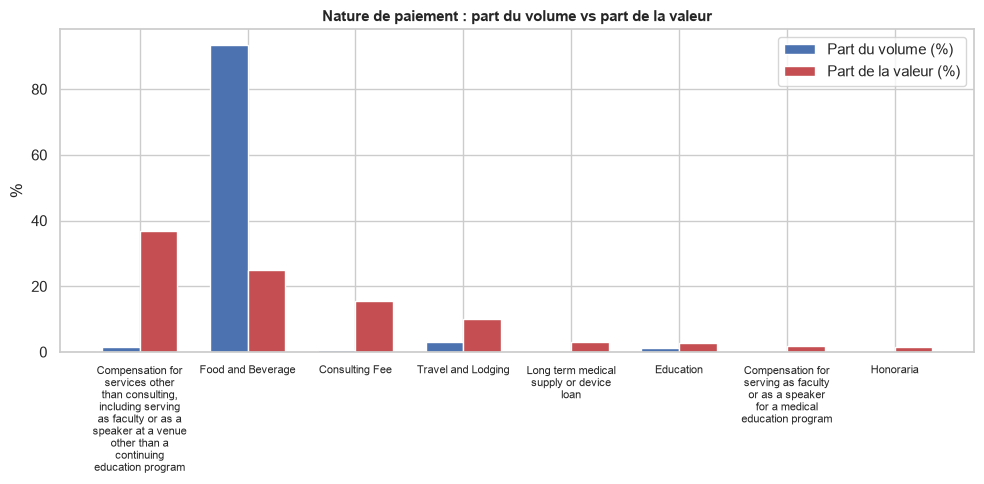

In [12]:
print("="*60)
print("4.3 NATURE DE PAIEMENT : VOLUME VS VALEUR")
print("="*60)

df_nat = pd.DataFrame({
    'nature': raw['nature_of_payment_or_transfer_of_value'],
    'montant': montant,
}).dropna()

agg_nat = df_nat.groupby('nature').agg(
    n_paiements=('montant', 'size'),
    montant_total=('montant', 'sum'),
    montant_moyen=('montant', 'mean'),
).sort_values('montant_total', ascending=False)

agg_nat['part_volume_%'] = (100 * agg_nat['n_paiements'] / agg_nat['n_paiements'].sum()).round(1)
agg_nat['part_valeur_%'] = (100 * agg_nat['montant_total'] / agg_nat['montant_total'].sum()).round(1)

agg_nat_disp = agg_nat.head(8).copy()
agg_nat_disp['montant_total'] = agg_nat_disp['montant_total'].map(lambda x: f"${x:,.0f}")
agg_nat_disp['montant_moyen'] = agg_nat_disp['montant_moyen'].map(lambda x: f"${x:,.0f}")
display(agg_nat_disp[['n_paiements', 'part_volume_%', 'montant_total', 'part_valeur_%', 'montant_moyen']])

fig, ax = plt.subplots(figsize=(10, 5))
top8 = agg_nat.head(8)
x = np.arange(len(top8))
width = 0.35
ax.bar(x - width/2, top8['part_volume_%'], width, label='Part du volume (%)', color="#4C72B0")
ax.bar(x + width/2, top8['part_valeur_%'], width, label='Part de la valeur (%)', color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels([textwrap.fill(l, 18) for l in top8.index], rotation=0, fontsize=8)
ax.set_ylabel('%')
ax.set_title("Nature de paiement : part du volume vs part de la valeur", fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

> **Observation.** Les repas et boissons (*Food and Beverage*) dominent très largement le volume (93,5 % des paiements) mais ne pèsent que 24,8 % de la valeur totale, pour un montant moyen de 23 \$ par paiement. À l'inverse, la première catégorie en valeur n'est pas la plus visible en volume : les interventions rémunérées hors conseil (*Compensation for services other than consulting*, faculty/conférencier) ne représentent que 1,4 % des paiements mais 36,9 % de la valeur totale (montant moyen 2 285 \$), devant les honoraires de conseil (*Consulting Fee*, 15,4 % de la valeur pour 0,6 % du volume, montant moyen 2 126 \$). Un professionnel très sollicité en nombre de paiements n'est donc pas nécessairement celui qui reçoit le plus de valeur.
>
> **Décision pour le Notebook 02** : calculer, en plus du montant total et du nombre de paiements, la **part de chaque nature dans le montant** (et pas seulement dans le volume) pour caractériser correctement le profil financier d'un professionnel.

## 5. Dynamique temporelle et concentration

Le dataset couvre deux années (2022 et 2023) et intègre une date de paiement précise (`date_of_payment`) que l'on n'avait pas exploitée jusqu'ici. Cette dimension est le pont direct vers l'objectif de rétention : elle permet d'observer la saisonnalité de l'engagement et de comparer les deux années avant de construire la cible.

### 5.1 Saisonnalité des paiements

5.1 SAISONNALITÉ MENSUELLE DES PAIEMENTS


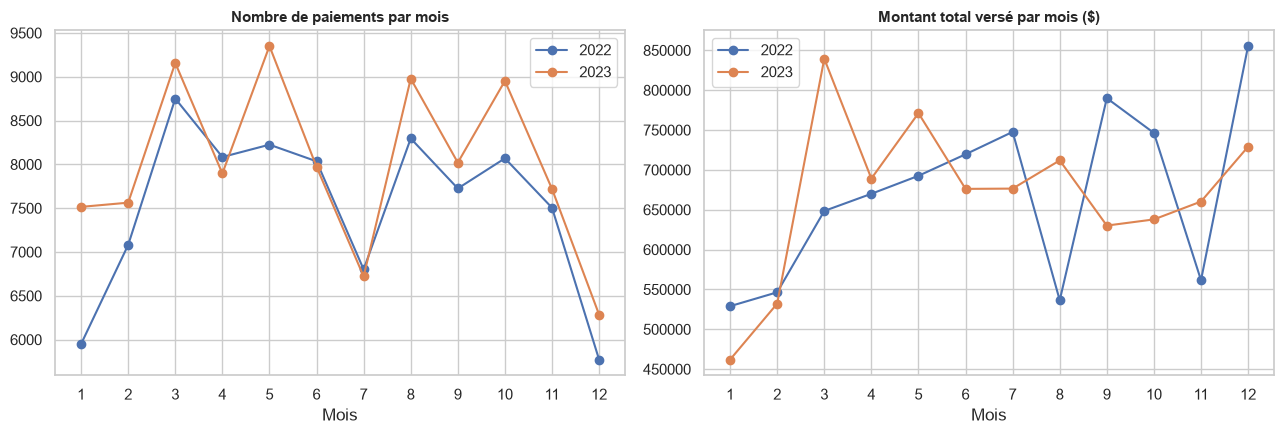

Pic de volume : mois 5 de 2023 (9,351 paiements)
Nombre de paiements sans date exploitable : 0 / 186,426


In [13]:
print("="*60)
print("5.1 SAISONNALITÉ MENSUELLE DES PAIEMENTS")
print("="*60)

dates = pd.to_datetime(raw['date_of_payment'], errors='coerce')
df_temps = pd.DataFrame({'date': dates, 'annee': raw['program_year'], 'montant': montant}).dropna(subset=['date'])
df_temps['mois'] = df_temps['date'].dt.month

mensuel = df_temps.groupby(['annee', 'mois']).agg(
    n_paiements=('montant', 'size'),
    montant_total=('montant', 'sum'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for an, grp in mensuel.groupby('annee'):
    grp = grp.sort_values('mois')
    axes[0].plot(grp['mois'], grp['n_paiements'], marker='o', label=str(an))
    axes[1].plot(grp['mois'], grp['montant_total'], marker='o', label=str(an))

axes[0].set_title("Nombre de paiements par mois", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Mois")
axes[0].set_xticks(range(1, 13))
axes[0].legend()

axes[1].set_title("Montant total versé par mois ($)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Mois")
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
plt.show()

pic = mensuel.loc[mensuel['n_paiements'].idxmax()]
print(f"Pic de volume : mois {int(pic['mois'])} de {int(pic['annee'])} ({pic['n_paiements']:,} paiements)")
print(f"Nombre de paiements sans date exploitable : {dates.isna().sum():,} / {len(raw):,}")

* **Pic de volume :** Mois 5 de 2023 (9 351 paiements)
* **Complétude temporelle :** Nombre de paiements sans date exploitable : 0 / 186 426 (couverture totale).

> **Observation :** Les paiements ne sont pas uniformément répartis sur l'année : un pic net apparaît en mai 2023 (9 351 paiements, contre une moyenne mensuelle d'environ 7 770 sur les deux années), ce qui correspond typiquement à la saison des grands congrès médicaux et des lancements de produits.
La couverture est complète : les 186 426 paiements ont tous une date exploitable (0 valeur manquante).

### 5.2 Évolution 2022 → 2023

In [14]:
print("="*60)
print("5.2 COMPARAISON ANNUELLE 2022 vs 2023")
print("="*60)

annee_int = raw['program_year'].astype(int)
df_annee = pd.DataFrame({'annee': annee_int, 'montant': montant, 'ps': raw['covered_recipient_profile_id']})
agg_annee = df_annee.groupby('annee').agg(
    n_paiements=('montant', 'size'),
    montant_total=('montant', 'sum'),
    n_professionnels=('ps', 'nunique'),
)
agg_annee['montant_moyen_par_ps'] = (agg_annee['montant_total'] / agg_annee['n_professionnels']).round(0)

display(agg_annee)

evolution_montant = 100 * (agg_annee.loc[2023, 'montant_total'] / agg_annee.loc[2022, 'montant_total'] - 1)
evolution_ps = 100 * (agg_annee.loc[2023, 'n_professionnels'] / agg_annee.loc[2022, 'n_professionnels'] - 1)
print(f"\nÉvolution du montant total 2022 -> 2023      : {evolution_montant:+.1f}%")
print(f"Évolution du nombre de professionnels payés  : {evolution_ps:+.1f}%")

5.2 COMPARAISON ANNUELLE 2022 vs 2023


,n_paiements,montant_total,n_professionnels,montant_moyen_par_ps
annee,,,,
2022,90294,8043488.83,5708,1409.0
2023,96132,8015997.89,6231,1286.0



Évolution du montant total 2022 -> 2023      : -0.3%
Évolution du nombre de professionnels payés  : +9.2%


> **Observation.** Le montant total versé est quasiment stable d'une année sur l'autre (**-0,3 %**, de 8,04 M\$ à 8,02 M\$), mais le nombre de professionnels payés augmente de **+9,2 %** (5 708 puis 6 231). Le budget se dilue donc sur davantage de professionnels : le montant moyen par professionnel recule de 1 409 \$ à 1 286 \$. Ce signal est cohérent avec l'objectif de rétention : l'entreprise semble élargir sa base de contacts plutôt qu'intensifier l'investissement sur les mêmes professionnels.

### 5.3 Concentration des montants : loi de Pareto

5.3 CONCENTRATION DES MONTANTS PAR PROFESSIONNEL (PARETO)


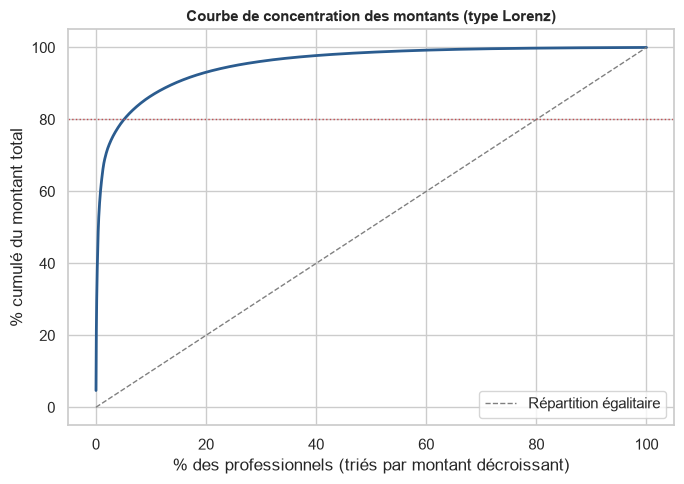

Part des professionnels qui concentrent 80% du montant total : 5.1%
Part du montant total captée par les 10% de professionnels les mieux payés : 86.5%


In [15]:
print("="*60)
print("5.3 CONCENTRATION DES MONTANTS PAR PROFESSIONNEL (PARETO)")
print("="*60)

df_ps = pd.DataFrame({'ps': raw['covered_recipient_profile_id'], 'montant': montant}).dropna(subset=['ps'])
montant_par_ps = df_ps.groupby('ps')['montant'].sum().sort_values(ascending=False)

part_cumulee = montant_par_ps.cumsum() / montant_par_ps.sum()
rang_pct = np.arange(1, len(montant_par_ps) + 1) / len(montant_par_ps)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rang_pct * 100, part_cumulee * 100, color="#2b5c8f", linewidth=2)
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', linewidth=1, label='Répartition égalitaire')
ax.axhline(80, color='#C44E52', linestyle=':', linewidth=1)
ax.set_xlabel("% des professionnels (triés par montant décroissant)")
ax.set_ylabel("% cumulé du montant total")
ax.set_title("Courbe de concentration des montants (type Lorenz)", fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

seuil_80 = (part_cumulee <= 0.80).sum() / len(part_cumulee) * 100
print(f"Part des professionnels qui concentrent 80% du montant total : {seuil_80:.1f}%")

top10_part = montant_par_ps.head(int(0.10 * len(montant_par_ps))).sum() / montant_par_ps.sum() * 100
print(f"Part du montant total captée par les 10% de professionnels les mieux payés : {top10_part:.1f}%")

> **Observation :** La courbe de Lorenz met en évidence une concentration extrême, bien au-delà de la règle classique du 80/20 : à peine **5,1 %** des professionnels concentrent **80 %** de la valeur totale, tandis que les **10 %** les mieux payés captent **86,5 %** des flux financiers. Cette asymétrie structurelle renforce la nécessité d'isoler et de segmenter finement ces profils à forte valeur pour la suite du projet. Un modèle ou une stratégie commerciale uniformes seraient mal adaptés à une population aussi inégalement engagée.

### 5.4 Part de marché des laboratoires

In [16]:
print("="*60)
print("5.4 PART DE MARCHÉ DES LABORATOIRES (VALEUR VERSÉE)")
print("="*60)

df_labo = pd.DataFrame({'labo': labo, 'montant': montant}).dropna()
montant_par_labo = df_labo.groupby('labo')['montant'].sum().sort_values(ascending=False)
part_par_labo = (100 * montant_par_labo / montant_par_labo.sum()).round(1)

top10_labos = pd.DataFrame({'montant_total': montant_par_labo.head(10), 'part_%': part_par_labo.head(10)})
top10_labos_disp = top10_labos.copy()
top10_labos_disp['montant_total'] = top10_labos_disp['montant_total'].map(lambda x: f"${x:,.0f}")
display(top10_labos_disp)

part_top5 = part_par_labo.head(5).sum()
part_top10 = part_par_labo.head(10).sum()
print(f"\nPart du montant total captée par les 5 premiers laboratoires  : {part_top5:.1f}%")
print(f"Part du montant total captée par les 10 premiers laboratoires : {part_top10:.1f}%")

5.4 PART DE MARCHÉ DES LABORATOIRES (VALEUR VERSÉE)


,montant_total,part_%
labo,,
ABBVIE INC.,"$2,052,287",12.8
ABBOTT LABORATORIES,"$840,809",5.2
"MEDTRONIC, INC.","$600,399",3.7
"JANSSEN PHARMACEUTICALS, INC","$585,874",3.6
"INTUITIVE SURGICAL, INC.","$584,204",3.6
"NEUROCRINE BIOSCIENCES, INC.","$510,147",3.2
"LILLY USA, LLC","$453,803",2.8
STRYKER CORPORATION,"$414,203",2.6
ASTRAZENECA PHARMACEUTICALS LP,"$389,933",2.4



Part du montant total captée par les 5 premiers laboratoires  : 28.9%
Part du montant total captée par les 10 premiers laboratoires : 42.2%


> **Observation.** Le marché est modérément concentré : les 5 premiers laboratoires versent **28,9 %** du montant total (ABBVIE INC. seul en capte 12,8 %) et les 10 premiers **42,2 %**. Le reste du montant est dispersé sur des dizaines de laboratoires plus petits, ce qui limite le risque de dépendance à un unique partenaire mais complexifie l'analyse du portefeuille commercial.

> **Décisions pour le Notebook 02 (issues des sections 4 et 5)** :
> 1. Conserver `date_of_payment` dans la base préparée : le modèle de rétention du Notebook 03 restera au grain annuel, mais la date permettra d'explorer une définition plus fine du churn dans une itération future.
> 2. Calculer, en plus du montant total par professionnel, la **part de chaque nature de paiement** dans son montant (feature comportementale).
> 3. Confirmer la nécessité de l'harmonisation des noms de laboratoires (`.str.upper().str.strip()`) avant tout calcul de part de marché, sous peine de sous-estimer la concentration réelle.


## 6. Vers la cible : la rétention 2022 → 2023

Idée du projet : un professionnel engagé (payé) en 2022 le sera-t-il encore en 2023 ? On mesure le recouvrement des professionnels entre les deux années.

In [17]:
print("="*60)
print("4. CONSTRUCTION DE LA VARIABLE CIBLE (RÉTENTION)")
print("="*60)

# Extraction des cohortes d'identifiants
annee = raw['program_year'].astype(int) # Convert to int
ids_2022 = set(raw.loc[annee == 2022, "covered_recipient_profile_id"].dropna())
ids_2023 = set(raw.loc[annee == 2023, "covered_recipient_profile_id"].dropna())

# Calcul de la rétention
retenus = len(ids_2022 & ids_2023)
perdus = len(ids_2022 - ids_2023)
total_2022 = len(ids_2022)

# Handle the case where total_2022 might be zero
if total_2022 == 0:
    taux_retention = 0.0
else:
    taux_retention = retenus / total_2022

print(f"Professionnels payés en 2022      : {total_2022:,}")
print(f"Encore payés en 2023 (Classe 1)   : {retenus:,}")
print(f"Non reconduits en 2023 (Classe 0) : {perdus:,}")
print(f"=> Taux de rétention              : {taux_retention:.1%}")

4. CONSTRUCTION DE LA VARIABLE CIBLE (RÉTENTION)


Professionnels payés en 2022      : 5,708
Encore payés en 2023 (Classe 1)   : 4,185
Non reconduits en 2023 (Classe 0) : 1,523
=> Taux de rétention              : 73.3%


> **Observation.** ~**73 %** des professionnels payés en 2022 le sont encore en 2023 : une cible **exploitable mais déséquilibrée** (majorité de "retenus"). Ce sera la variable à prédire, construite en préparation.

> **Impact pour la suite du projet (Notebook 02 & 03) :**
>
> 1. **Périmètre d'apprentissage** : La population d'étude pour le modèle sera constituée des **5 708 professionnels actifs en 2022**.
> 2. **Prévention du *Data Leakage*** : Toutes les variables explicatives (*features*) seront construites **strictement sur les données 2022** pour prédire le statut en 2023.
> 3. **Choix des métriques** : L'évaluation des modèles de classification s'appuiera sur le **F1-Score**, l'**AUC-ROC** et la matrice de confusion.



### 6.2 Fidélité concurrentielle : exclusivité vs multi-laboratoires

6.2 EXCLUSIVITÉ LABORATOIRE ET RÉTENTION


Professionnels 2022 avec un seul laboratoire partenaire : 2,265 (39.7%)
Professionnels 2022 avec plusieurs laboratoires         : 3,443 (60.3%)

Taux de rétention (1 seul laboratoire)      : 50.8%
Taux de rétention (plusieurs laboratoires)  : 88.1%


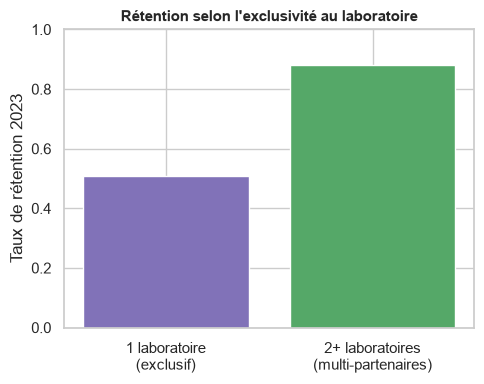

In [18]:
print("="*60)
print("6.2 EXCLUSIVITÉ LABORATOIRE ET RÉTENTION")
print("="*60)

raw_2022 = raw[raw['program_year'].astype(int) == 2022].dropna(subset=['covered_recipient_profile_id'])
n_labs_2022 = raw_2022.groupby('covered_recipient_profile_id')[
    'applicable_manufacturer_or_applicable_gpo_making_payment_name'
].apply(lambda s: s.str.upper().str.strip().nunique())

exclusif = (n_labs_2022 == 1)
print(f"Professionnels 2022 avec un seul laboratoire partenaire : {exclusif.sum():,} ({100*exclusif.mean():.1f}%)")
print(f"Professionnels 2022 avec plusieurs laboratoires         : {(~exclusif).sum():,} ({100*(~exclusif).mean():.1f}%)")

retenu_par_ps = n_labs_2022.index.to_series().apply(lambda x: x in ids_2023)
taux_retention_exclusif = retenu_par_ps[exclusif].mean()
taux_retention_multi = retenu_par_ps[~exclusif].mean()

print(f"\nTaux de rétention (1 seul laboratoire)      : {taux_retention_exclusif:.1%}")
print(f"Taux de rétention (plusieurs laboratoires)  : {taux_retention_multi:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['1 laboratoire\n(exclusif)', '2+ laboratoires\n(multi-partenaires)'],
       [taux_retention_exclusif, taux_retention_multi], color=["#8172B8", "#55A868"])
ax.set_ylabel("Taux de rétention 2023")
ax.set_title("Rétention selon l'exclusivité au laboratoire", fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

> **Observation.** L'écart est considérable, l'exclusivité n'est pas un gage de fidélité : un professionnel qui ne travaille qu'avec un seul laboratoire en 2022 n'est retenu qu'à **50,8 %** en 2023, contre **88,1 %** pour un professionnel qui interagit avec plusieurs laboratoires, soit un écart de plus de 37 points. Le nombre de laboratoires partenaires est l'un des signaux les plus discriminants observés dans cette exploration, plus net encore que la simple intensité de paiement. `n_labs_2022` doit être conservé comme feature à part entière pour le modèle du Notebook 03.

### 6.3 Vers une définition plus fine du churn (pistes pour de futures itérations)

La cible retenue pour ce projet est volontairement simple : `retenu` = le professionnel de 2022 reçoit-il au moins un paiement en 2023 ? Cette définition binaire est robuste et facile à interpréter, mais elle capture mal les situations intermédiaires. Deux définitions alternatives, rendues possibles par la présence de `date_of_payment`, pourraient être explorées dans une itération future :

* **Arrêt prolongé** : un professionnel est considéré perdu s'il ne reçoit plus aucun paiement pendant 6 mois consécutifs, plutôt que sur la seule base d'un changement d'année civile.
* **Baisse d'engagement** : un professionnel est considéré en risque de churn si son montant cumulé chute de plus de 50 % entre 2022 et 2023, même s'il reçoit encore au moins un paiement.

**Décision pour ce projet** : conserver la définition binaire annuelle pour les Notebooks 02 et 03, car elle correspond à un périmètre de données propre (deux années complètes) et reste la plus interprétable pour une preuve de concept. Les définitions plus fines sont documentées ici comme axe d'amélioration, et `n_labs_2022` (nombre de laboratoires distincts) rejoint la liste des features à construire au Notebook 02, puisqu'elle est corrélée à la rétention.

## 7. Conclusion et synthèse générale

L'exploration approfondie menée dans ce premier carnet a permis de poser des bases méthodologiques solides pour le projet de modélisation prédictive de la rétention des professionnels de santé. Les principaux enseignements structurants qui se dégagent de cette analyse exploratoire sont les suivants :

* **Dissociation entre Volume et Valeur :** Les volumes transactionnels sont écrasamment dominés par les dépenses de type *Food and Beverage* (93,5 % des paiements pour un montant unitaire moyen très faible de 23 $), tandis que la valeur financière réelle est captée par des prestations à forte valeur ajoutée telles que les honoraires de conseil (*Consulting Fee*) ou les services spécialisés.
* **Concentration Asymétrique (Loi de Pareto) :** La répartition des montants versés présente une inégale distribution bien plus marquée que la règle classique du 80/20, puisque 5,1 % des professionnels captent à eux seuls 80 % de la valeur totale.
* **Évolution Budgétaire et Stratégie :** Entre 2022 et 2023, le montant total versé est demeuré globalement stable (-0,3 %), mais s'est dilué sur une base de professionnels élargie (+9,2 %), illustrant une volonté d'extension du réseau de contacts.
* **Enseignement Majeur sur la Rétention :** L'analyse de la cible binaire (taux de rétention global de 73,3 %) bat en brèche l'intuition de l'exclusivité : les professionnels collaborant avec plusieurs laboratoires affichent un taux de fidélité spectaculaire de 88,1 %, contre 50,8 % pour les profils exclusifs, faisant du multi-partenariat un prédicteur clé.

Ces constats valident l'ensemble des choix d'ingénierie et la feuille de route opérationnelle définie pour aborder la phase de préparation des données du **Notebook 02** dans des conditions optimales, prêtes pour la modélisation.

## Décisions de préparation (Feuille de route pour le Notebook 02)

L'exploration globale (EDA) de la base brute met en évidence plusieurs impératifs techniques et méthodologiques. Afin d'éviter les redondances, l'ensemble de la feuille de route opérationnelle pour la phase de préparation des données du **Notebook 02** est directement synthétisé dans le tableau ci-dessous :

| Catégorie | Action à réaliser | Justification / Objectif technique |
| :--- | :--- | :--- |
| **1. Nettoyage & Filtrage** | • Dédoublonnage strict (`drop_duplicates` sur toutes les colonnes)<br>• Typage (`float` pour montants, `int` pour l'année)<br>• Normalisation texte (`.str.upper().str.strip()`)<br>• Exclusion des hôpitaux d'enseignement | • Éliminer les artefacts d'ingestion (0,65%)<br>• Garantir des calculs mathématiques corrects<br>• Assurer un comptage exact des labos<br>• Se concentrer strictement sur les praticiens (HCP) |
| **2. Feature Engineering** | • Extraire le 1er niveau de spécialité (`covered_recipient_specialty_1`) | • Isoler la grande famille de spécialité via le séparateur `\|` |
| **3. Agrégation Individu (2022)** | • Créer la table (1 ligne = 1 PS actif en 2022) :<br>  - Volume financier (somme, moyenne, médiane)<br>  - Intensité relationnelle (compte total)<br>  - Diversité (`nunique` labos et natures)<br>  - Profil d'engagement (spécialité mode & parts) | • Structurer la population d'apprentissage (5 708 profils)<br>• Caractériser finement l'activité financière et relationnelle |
| **4. Construction de la Target** | • Créer `retenu_2023` (1 si actif en 2023, 0 sinon)<br>• Appliquer une isolation temporelle stricte sur 2022 | • Définir la cible du modèle de prédiction (26,7% d'attrition)<br>• Empêcher tout risque de *Data Leakage* |
| **5. Intégration des Insights EDA** | • Calculer la part de valeur par nature de paiement<br>• Conserver `n_labs_2022` (exclusivité vs multi-labos)<br>• Maintenir la colonne `date_of_payment` | • Capturer la vraie valeur (conseil/recherche vs repas)<br>• Intégrer le marqueur fort de rétention multi-partenaires<br>• Préserver l'historique temporel pour de futures itérations |